In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
user_task_submissions = pd.read_csv(
    "submissions_archive/user_task_submissions.csv",
    sep=";",
    encoding="utf-8-sig"
)

task_competence_mapping = pd.read_csv(
    "submissions_archive/task_competence_mapping.csv",
    sep=";",
    encoding="utf-8-sig"
)

print("user_task_submissions:", user_task_submissions.shape)
print("task_competence_mapping:", task_competence_mapping.shape)

user_task_submissions: (2766, 17)
task_competence_mapping: (1613, 10)

Колонки user_task_submissions:
['user_id', 'user_number', 'submission_id', 'practice_submission_id', 'task_id', 'task_name', 'task_type', 'max_score', 'node_id', 'node_name', 'course_id', 'task_number', 'status', 'score', 'autochecked', 'submission_time', 'is_correct']

Колонки task_competence_mapping:
['task_id', 'task_name', 'task_type', 'node_id', 'node_name', 'course_id', 'task_number', 'competence_id', 'competence_code', 'competence_name']


In [ ]:
user_task_submissions = user_task_submissions[["user_id", "task_id", "is_correct"]].copy()
task_competence_mapping = task_competence_mapping[["task_id", "competence_id"]].copy()

user_task_submissions["user_id"] = user_task_submissions["user_id"].astype(str)
user_task_submissions["task_id"] = user_task_submissions["task_id"].astype(str)
task_competence_mapping["task_id"] = task_competence_mapping["task_id"].astype(str)
task_competence_mapping["competence_id"] = task_competence_mapping["competence_id"].astype(str)

user_task_submissions["is_correct"] = (
    user_task_submissions["is_correct"]
    .astype(str)
    .str.strip()
    .replace({
        "True": 1, "False": 0,
        "true": 1, "false": 0,
        "1": 1, "0": 0
    })
)

user_task_submissions["is_correct"] = pd.to_numeric(
    user_task_submissions["is_correct"],
    errors="coerce"
)

user_task_submissions = user_task_submissions.dropna(subset=["is_correct"])
user_task_submissions["is_correct"] = user_task_submissions["is_correct"].astype(int)

print(user_task_submissions.head())
print(task_competence_mapping.head())

                                user_id                               task_id  \
0  6ef78882-a6ad-4911-a29a-ff23fa5702d4  86405780-d6f8-4877-a8b8-44fd1b85e682   
1  6ef78882-a6ad-4911-a29a-ff23fa5702d4  0d4a0fe0-22ef-4946-ba24-d840790a867b   
2  6ef78882-a6ad-4911-a29a-ff23fa5702d4  12882d19-6515-4eda-8f15-4f030739d9ba   
3  6ef78882-a6ad-4911-a29a-ff23fa5702d4  b60ed278-24f3-44d6-950b-424d67099abb   
4  6ef78882-a6ad-4911-a29a-ff23fa5702d4  7302abe8-ccb5-4164-9caa-092e767ae4d6   

   is_correct  
0           1  
1           1  
2           1  
3           1  
4           1  
                                task_id                         competence_id
0  18200de2-8927-49e2-abe0-1182e6e6c82a  6a379d79-219c-4c02-a18a-fc4d5439e209
1  9a214a3c-5bc1-431b-9adc-f6d26e6f17b0  6a379d79-219c-4c02-a18a-fc4d5439e209
2  d8ea6c9f-7687-45c2-a7cc-59a6b53c735e  6a379d79-219c-4c02-a18a-fc4d5439e209
3  a6c5b2e1-c0bd-4f1f-8786-9d9742ffb51f  6a379d79-219c-4c02-a18a-fc4d5439e209
4  93480de3-f5e5-44ff-a2d5-

/var/folders/jd/4wtjx1r11c59_b4xs26x5b8r0000gn/T/ipykernel_39537/3854666098.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({


In [ ]:
# Объединение логов с компетенциями
df = user_task_submissions.merge(
    task_competence_mapping,
    on="task_id",
    how="inner"
)

print("После merge:", df.shape)
print(df.head())

# 3. Агрегация: attempts, correct, mastery
agg = (
    df.groupby(["user_id", "competence_id"])
      .agg(
          attempts=("is_correct", "count"),
          correct=("is_correct", "sum")
      )
      .reset_index()
)

agg["mastery"] = (agg["correct"] + 1) / (agg["attempts"] + 2)

print(agg.head())

# Pivot: User × Competence
user_comp_matrix = agg.pivot(
    index="user_id",
    columns="competence_id",
    values="mastery"
)

# Пользователь не сталкивался с компетенцией
user_comp_matrix = user_comp_matrix.fillna(0)

print("Матрица User × Competence:", user_comp_matrix.shape)
display(user_comp_matrix.head())

После merge: (7083, 4)
                                user_id                               task_id  \
0  6ef78882-a6ad-4911-a29a-ff23fa5702d4  86405780-d6f8-4877-a8b8-44fd1b85e682   
1  6ef78882-a6ad-4911-a29a-ff23fa5702d4  86405780-d6f8-4877-a8b8-44fd1b85e682   
2  6ef78882-a6ad-4911-a29a-ff23fa5702d4  86405780-d6f8-4877-a8b8-44fd1b85e682   
3  6ef78882-a6ad-4911-a29a-ff23fa5702d4  0d4a0fe0-22ef-4946-ba24-d840790a867b   
4  6ef78882-a6ad-4911-a29a-ff23fa5702d4  0d4a0fe0-22ef-4946-ba24-d840790a867b   

   is_correct                         competence_id  
0           1  8d11bcaf-582a-44e2-b216-0bacdf1cfb9f  
1           1  5bfdfb46-d0df-4cc4-a844-e4f8aea90fdb  
2           1  098cafdf-6cf4-472b-a27d-17649fab3eff  
3           1  118d8585-a00f-46f7-be45-0a39fc33f401  
4           1  078423e2-9dcd-4e8e-9887-702ee08b0153  
                                user_id                         competence_id  \
0  04faac8a-55ba-45e8-b22b-3defa5512390  078423e2-9dcd-4e8e-9887-702ee08b0153   
1  0

competence_id,0092b753-5923-4b1f-b958-87d133d8a040,011e098a-aca2-4098-b496-95d0118d950b,078423e2-9dcd-4e8e-9887-702ee08b0153,08d0fc0a-b8e2-41a4-91a6-7e4daab9083d,098cafdf-6cf4-472b-a27d-17649fab3eff,0aab5cb4-22b6-41a8-98b7-4086d658d01e,0e6e94f7-af5a-43d5-8d74-71a414f74deb,1024e3ec-6786-4059-84fe-3ae001527444,10a8e01b-d429-47d1-a81f-d71dcf486c7e,118d8585-a00f-46f7-be45-0a39fc33f401,...,df8609c2-5e99-448b-ae5f-1260717c8e0d,e0bf6fb3-c7cf-47af-8f34-aa79a7837321,e1399bbe-1b3e-479c-a32a-cca18683b6b6,e28b7ebb-d852-472a-8b46-99621bf850d1,e665fd49-2351-400b-a091-24f198dd8421,ebd0acf1-13ca-45e0-b7a5-4ebcd6dbb89e,ee739efb-4e90-4fd8-9bc4-b25675831508,f6169ea7-2547-4c0e-b4c6-26688f45eb9d,fd89bd31-ff34-40e2-a4c5-80f91f1ef93c,fe63c5a4-ca33-49e5-841b-6340c788b9f4
user_id,,,,,,,,,,,,,,,,,,,,,
04faac8a-55ba-45e8-b22b-3defa5512390,0.000000,0.0,0.875000,0.0,0.000000,0.000000,0.000000,0.500000,0.000000,0.75,...,0.000000,0.954545,0.000000,0.833333,0.000000,0.000000,0.000000,0.00,0.666667,0.0
0e24ff0e-c58a-4a6c-b054-e80df6607b99,0.666667,0.0,0.750000,0.0,0.000000,0.000000,0.666667,0.666667,0.666667,0.00,...,0.666667,0.666667,0.000000,0.666667,0.000000,0.666667,0.000000,0.00,0.000000,0.0
17993c65-1f0e-4f0a-b458-a7c688b99ea0,0.375000,0.0,0.727273,0.0,0.562500,0.000000,0.391304,0.500000,0.592593,0.00,...,0.375000,0.500000,0.333333,0.714286,0.166667,0.631579,0.166667,0.75,0.375000,0.0
2313e3e0-a834-4dfd-a62e-da6bf6bab116,0.000000,0.0,0.400000,0.0,0.000000,0.000000,0.000000,0.000000,0.333333,0.00,...,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.00,0.333333,0.0
363f7164-3a52-43aa-8b9b-b1677ed218ec,0.571429,0.0,0.771429,0.0,0.857143,0.833333,0.722222,0.714286,0.631579,0.80,...,0.571429,0.777778,0.000000,0.933333,0.833333,0.333333,0.875000,0.75,0.666667,0.0


In [ ]:
n_users, n_comp = user_comp_matrix.shape
density = (user_comp_matrix != 0).sum().sum() / (n_users * n_comp)

print(f"Число пользователей: {n_users}")
print(f"Число компетенций: {n_comp}")
print(f"Плотность матрицы: {density:.4f}")
print(f"Разреженность: {1 - density:.4f}")

avg_nonzero_per_user = (user_comp_matrix != 0).sum(axis=1).mean()
print(f"Среднее число ненулевых компетенций на пользователя: {avg_nonzero_per_user:.2f}")

Число пользователей: 33
Число компетенций: 98
Плотность матрицы: 0.3899
Разреженность: 0.6101
Среднее число ненулевых компетенций на пользователя: 38.21


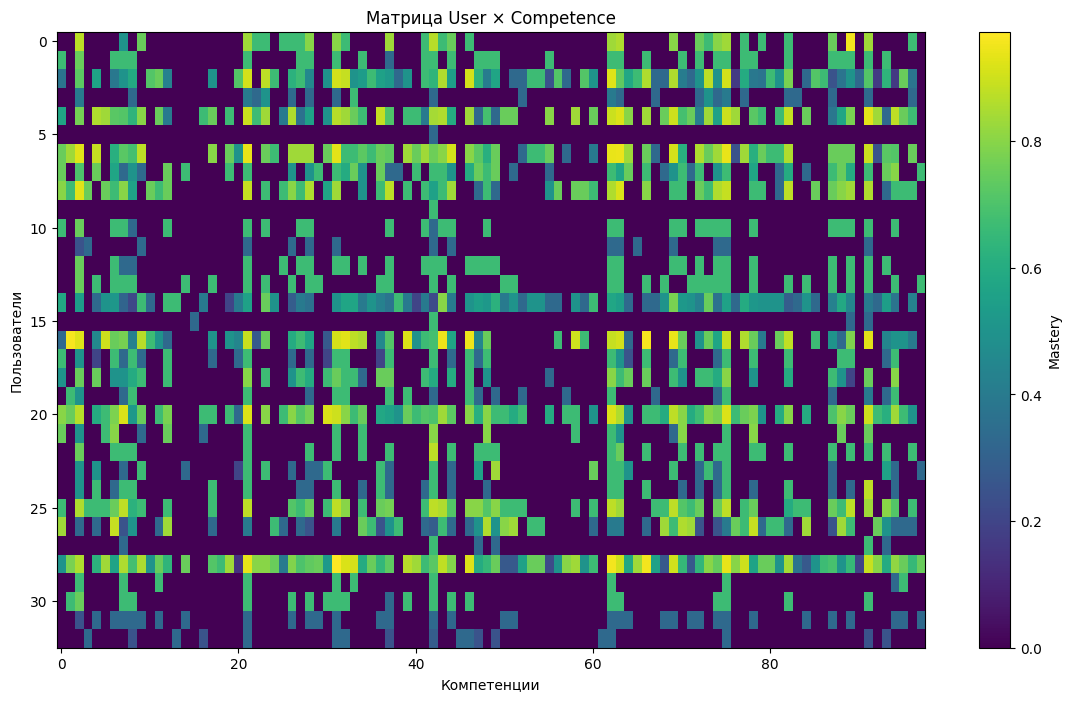

In [25]:
plt.figure(figsize=(14, 8))
plt.imshow(user_comp_matrix.values, aspect='auto')
plt.colorbar(label='Mastery')
plt.title("Матрица User × Competence")
plt.xlabel("Компетенции")
plt.ylabel("Пользователи")
plt.show()

SVD

In [ ]:
# Нормализация

scaler_users = StandardScaler()
X_users = scaler_users.fit_transform(user_comp_matrix)

scaler_comp = StandardScaler()
X_comp = scaler_comp.fit_transform(user_comp_matrix.T)

print(X_users.shape, X_comp.shape)

(33, 98) (98, 33)


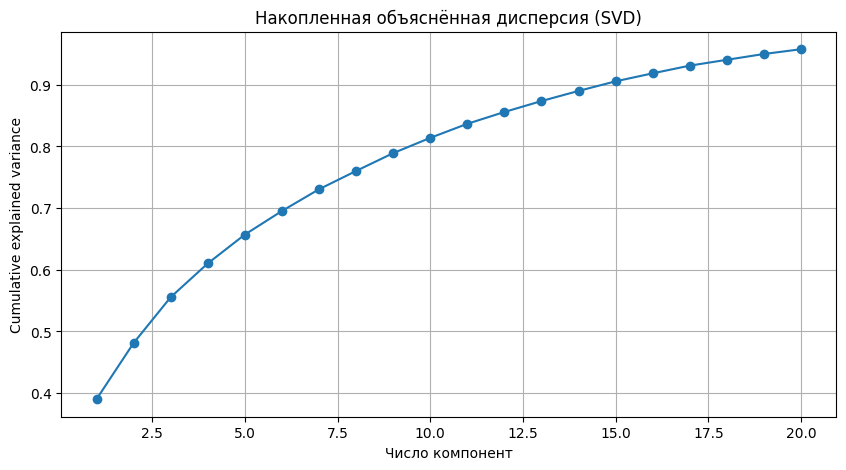

Explained variance ratio:
Компонента 1: 0.3898
Компонента 2: 0.0912
Компонента 3: 0.0743
Компонента 4: 0.0548
Компонента 5: 0.0468
Компонента 6: 0.0382
Компонента 7: 0.0353
Компонента 8: 0.0297
Компонента 9: 0.0289
Компонента 10: 0.0248
Компонента 11: 0.0228
Компонента 12: 0.0192
Компонента 13: 0.0178
Компонента 14: 0.0164
Компонента 15: 0.0156
Компонента 16: 0.0130
Компонента 17: 0.0125
Компонента 18: 0.0095
Компонента 19: 0.0094
Компонента 20: 0.0077
Латентное представление пользователей: (33, 5)


In [27]:
# SVD для пользователей

max_components = min(20, X_users.shape[0]-1, X_users.shape[1]-1)
svd = TruncatedSVD(n_components=max_components, random_state=42)
X_users_svd = svd.fit_transform(X_users)

explained = svd.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker='o')
plt.title("Накопленная объяснённая дисперсия (SVD)")
plt.xlabel("Число компонент")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

print("Explained variance ratio:")
for i, val in enumerate(explained, start=1):
    print(f"Компонента {i}: {val:.4f}")

k_svd = min(5, X_users_svd.shape[1])
X_users_latent = X_users_svd[:, :k_svd]

print("Латентное представление пользователей:", X_users_latent.shape)

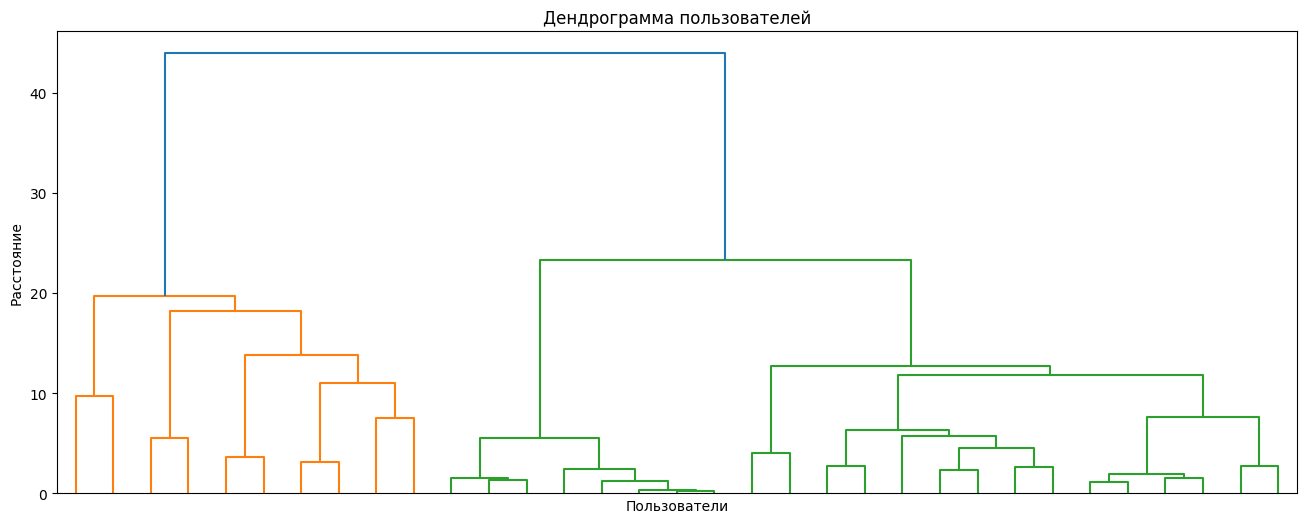

In [28]:
Z_users = linkage(X_users_latent, method="ward")

plt.figure(figsize=(16, 6))
dendrogram(Z_users, no_labels=True)
plt.title("Дендрограмма пользователей")
plt.xlabel("Пользователи")
plt.ylabel("Расстояние")
plt.show()

In [30]:
n_user_clusters = 3

user_model = AgglomerativeClustering(
    n_clusters=n_user_clusters,
    metric="euclidean",
    linkage="ward"
)

user_labels = user_model.fit_predict(X_users_latent)

user_clusters = user_comp_matrix.copy()
user_clusters["user_cluster"] = user_labels

display(user_clusters.head())
print(user_clusters["user_cluster"].value_counts().sort_index())

competence_id,0092b753-5923-4b1f-b958-87d133d8a040,011e098a-aca2-4098-b496-95d0118d950b,078423e2-9dcd-4e8e-9887-702ee08b0153,08d0fc0a-b8e2-41a4-91a6-7e4daab9083d,098cafdf-6cf4-472b-a27d-17649fab3eff,0aab5cb4-22b6-41a8-98b7-4086d658d01e,0e6e94f7-af5a-43d5-8d74-71a414f74deb,1024e3ec-6786-4059-84fe-3ae001527444,10a8e01b-d429-47d1-a81f-d71dcf486c7e,118d8585-a00f-46f7-be45-0a39fc33f401,...,e0bf6fb3-c7cf-47af-8f34-aa79a7837321,e1399bbe-1b3e-479c-a32a-cca18683b6b6,e28b7ebb-d852-472a-8b46-99621bf850d1,e665fd49-2351-400b-a091-24f198dd8421,ebd0acf1-13ca-45e0-b7a5-4ebcd6dbb89e,ee739efb-4e90-4fd8-9bc4-b25675831508,f6169ea7-2547-4c0e-b4c6-26688f45eb9d,fd89bd31-ff34-40e2-a4c5-80f91f1ef93c,fe63c5a4-ca33-49e5-841b-6340c788b9f4,user_cluster
user_id,,,,,,,,,,,,,,,,,,,,,
04faac8a-55ba-45e8-b22b-3defa5512390,0.000000,0.0,0.875000,0.0,0.000000,0.000000,0.000000,0.500000,0.000000,0.75,...,0.954545,0.000000,0.833333,0.000000,0.000000,0.000000,0.00,0.666667,0.0,1
0e24ff0e-c58a-4a6c-b054-e80df6607b99,0.666667,0.0,0.750000,0.0,0.000000,0.000000,0.666667,0.666667,0.666667,0.00,...,0.666667,0.000000,0.666667,0.000000,0.666667,0.000000,0.00,0.000000,0.0,1
17993c65-1f0e-4f0a-b458-a7c688b99ea0,0.375000,0.0,0.727273,0.0,0.562500,0.000000,0.391304,0.500000,0.592593,0.00,...,0.500000,0.333333,0.714286,0.166667,0.631579,0.166667,0.75,0.375000,0.0,0
2313e3e0-a834-4dfd-a62e-da6bf6bab116,0.000000,0.0,0.400000,0.0,0.000000,0.000000,0.000000,0.000000,0.333333,0.00,...,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.00,0.333333,0.0,2
363f7164-3a52-43aa-8b9b-b1677ed218ec,0.571429,0.0,0.771429,0.0,0.857143,0.833333,0.722222,0.714286,0.631579,0.80,...,0.777778,0.000000,0.933333,0.833333,0.333333,0.875000,0.75,0.666667,0.0,0


user_cluster
0    10
1    15
2     8
Name: count, dtype: int64


In [31]:
cluster_profiles = user_clusters.groupby("user_cluster").mean()
display(cluster_profiles)

competence_id,0092b753-5923-4b1f-b958-87d133d8a040,011e098a-aca2-4098-b496-95d0118d950b,078423e2-9dcd-4e8e-9887-702ee08b0153,08d0fc0a-b8e2-41a4-91a6-7e4daab9083d,098cafdf-6cf4-472b-a27d-17649fab3eff,0aab5cb4-22b6-41a8-98b7-4086d658d01e,0e6e94f7-af5a-43d5-8d74-71a414f74deb,1024e3ec-6786-4059-84fe-3ae001527444,10a8e01b-d429-47d1-a81f-d71dcf486c7e,118d8585-a00f-46f7-be45-0a39fc33f401,...,df8609c2-5e99-448b-ae5f-1260717c8e0d,e0bf6fb3-c7cf-47af-8f34-aa79a7837321,e1399bbe-1b3e-479c-a32a-cca18683b6b6,e28b7ebb-d852-472a-8b46-99621bf850d1,e665fd49-2351-400b-a091-24f198dd8421,ebd0acf1-13ca-45e0-b7a5-4ebcd6dbb89e,ee739efb-4e90-4fd8-9bc4-b25675831508,f6169ea7-2547-4c0e-b4c6-26688f45eb9d,fd89bd31-ff34-40e2-a4c5-80f91f1ef93c,fe63c5a4-ca33-49e5-841b-6340c788b9f4
user_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.621800,0.398611,0.773641,0.141667,0.532141,0.515000,0.664744,0.671795,0.543172,0.547500,...,0.621800,0.703294,0.053333,0.735181,0.38,0.552575,0.599107,0.441667,0.543690,0.075000
1,0.266667,0.088889,0.638333,0.000000,0.257778,0.044444,0.435873,0.466667,0.451111,0.227778,...,0.266667,0.428081,0.000000,0.551667,0.00,0.264815,0.351111,0.022222,0.088889,0.133333
2,0.000000,0.000000,0.164583,0.083333,0.000000,0.000000,0.000000,0.125000,0.072917,0.041667,...,0.000000,0.041667,0.000000,0.239583,0.00,0.072917,0.041667,0.083333,0.041667,0.000000


Агломеративная кластеризация компетенций по столбцам

In [33]:
max_components_comp = min(10, X_comp.shape[0]-1, X_comp.shape[1]-1)

if max_components_comp >= 2:
    svd_comp = TruncatedSVD(n_components=max_components_comp, random_state=42)
    X_comp_svd = svd_comp.fit_transform(X_comp)
    k_comp = min(5, X_comp_svd.shape[1])
    X_comp_latent = X_comp_svd[:, :k_comp]
else:
    X_comp_latent = X_comp

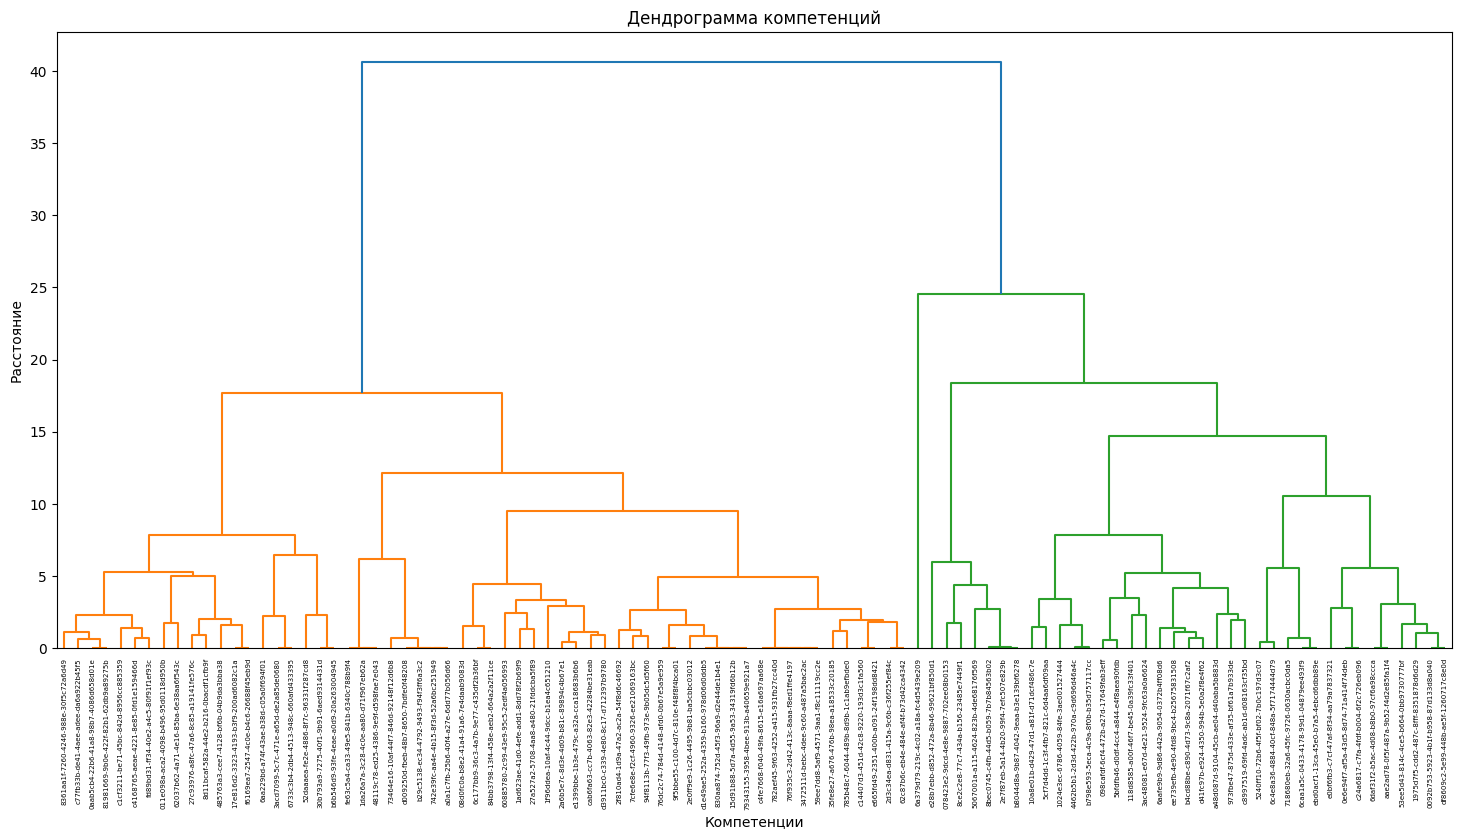

In [34]:
Z_comp = linkage(X_comp_latent, method="ward")

plt.figure(figsize=(18, 8))
dendrogram(
    Z_comp,
    labels=user_comp_matrix.columns.astype(str).tolist(),
    leaf_rotation=90
)
plt.title("Дендрограмма компетенций")
plt.xlabel("Компетенции")
plt.ylabel("Расстояние")
plt.show()

In [37]:
n_comp_clusters = 2

comp_model = AgglomerativeClustering(
    n_clusters=n_comp_clusters,
    metric="euclidean",
    linkage="ward"
)

comp_labels = comp_model.fit_predict(X_comp_latent)

comp_clusters = pd.DataFrame({
    "competence_id": user_comp_matrix.columns,
    "competence_cluster": comp_labels
})

display(comp_clusters.sort_values("competence_cluster"))
print(comp_clusters["competence_cluster"].value_counts().sort_index())

,competence_id,competence_cluster
0,0092b753-5923-4b1f-b958-87d133d8a040,0
32,5240ff10-72b6-4f5f-bf02-7b0c197d3c07,0
34,53ee5d43-814c-4ce5-b664-0bb9730777bf,0
36,5bfdfb46-d0df-4cc4-a844-e4f8aea90fdb,0
37,5cf7d4dd-1c3f-4fb7-821c-6d4aa6df09aa,0
...,...,...
59,830aa874-752d-45f3-96a9-d2e44de1b4e1,1
60,8361aa1f-7260-4246-988e-30f5c72a6d49,1
61,84bb3798-13f4-458e-aeb2-664a2a2f11ce,1
18,2a6b5e7c-8d3e-4d09-b81c-89894c4b67e1,1


competence_cluster
0    38
1    60
Name: count, dtype: int64
